In [1]:
import sys
sys.path.append('..')

from shipClass.Ship import Ship
from shipClass.SensedShip import SensedShip

import numpy.random as npr
npr.seed(1)  # for reproducibility

In [10]:
(189+184)/720

(296.67+50)/720



0.4814861111111111

In [2]:
import numpy as np
num_simulations  = 100
numpy_random_seeds = np.arange(num_simulations)
print(numpy_random_seeds)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


### MAIN GOAL : to compare different number of sensors and sensor quality levels

No Parallelization, Progress Bar

In [ ]:
from utils.helperFunctions import compress_folder_to_zip, create_multi_simulation_table
from simCalcFunctions import *

import cProfile
import pstats
import numpy as np
from tqdm import tqdm

def main():
    num_simulations = 100   # number of times to run each simulation parameter

    simulation_parameters=[ (1, 'bad'),        # 1 bad quality sensor per component
                            (1, 'moderate'),   # 1 moderate quality sensor per component
                            (1, 'good'),       # 1 good quality sensor per component
                            (3, 'bad'),        # 3 bad quality sensors per component
                            (3, 'moderate'),   # 3 moderate quality sensors per component
                            (3, 'good'),       # 3 good quality sensors per component
                            (7, 'bad'),        # 7 bad quality sensors per component
                            (7, 'moderate'),   # 7 moderate quality sensors per component
                            (7, 'good')]       # 7 good quality sensors per component

    # set up lists for storing relevant data
    count_correct_readings = np.zeros((len(simulation_parameters), num_simulations))
    count_incorrect_readings = np.zeros((len(simulation_parameters), num_simulations))
    count_missed_failures = np.zeros((len(simulation_parameters), num_simulations)) # truth = 0 ; sensed !=0
    count_false_alarms = np.zeros((len(simulation_parameters), num_simulations))    # truth = 0 ; sensed = 1
    count_unsensed_failues = np.zeros((len(simulation_parameters), num_simulations))  # truth != 0 ; sensed = 0
    count_unsensed_alarms = np.zeros((len(simulation_parameters), num_simulations))   # truth != 1 ; sensed = 1

    # initialize a repairable ship
    repairable_aux_ship = Ship(
        'RepairableShip',
        'auxiliary_ship_data.xlsx',
        repairable=True
    )

    # run the simulations
    for i, (num_sensors, quality) in enumerate(simulation_parameters):
        desc = f"Sensors={num_sensors}, Quality={quality}"
        
        for j in tqdm(range(num_simulations), desc=desc):
            # attach sensors to the ship
            sensors = [[(num_sensors, quality) for comps in system.comps]
                       for system in repairable_aux_ship.systems.values()]
            sensed_R_aux_ship = SensedShip(repairable_aux_ship, sensors)
            sensed_R_aux_ship.attach_sensors()

            # simulate for 1440 hours (60 days)
            sensed_R_aux_ship.simulate(1440)

            # calculate relevant data
            truth_history = sensed_R_aux_ship.ship.history
            sensed_history = sensed_R_aux_ship.sensedHistory
            correct_readings, incorrect_readings = countRightAndWrongReadings(truth_history, sensed_history)
            missed_failures, false_alarms = countFalseNegatives(truth_history, sensed_history)
            unsensed_fails, unsensed_alarms = countFalsePositives(truth_history, sensed_history)

            # working_steps, failed_steps = sensed_R_aux_ship.countAllReadings()
            count_correct_readings[i][j] = correct_readings
            count_incorrect_readings[i][j] = incorrect_readings
            count_missed_failures[i][j] = missed_failures
            count_false_alarms[i][j] = false_alarms
            count_unsensed_failues[i][j] = unsensed_fails
            count_unsensed_alarms[i][j] = unsensed_alarms

            # reset the ship for the next simulation
            sensed_R_aux_ship.reset()

    # print out results
    headers = ["Simulation Parameters", "Correct Readings", "Incorrect Readings"]
    rows = []
    for i, param in enumerate(simulation_parameters):
        rows.append([
            param,
            count_correct_readings[i].mean(),
            count_incorrect_readings[i].mean()
        ])
    print(create_multi_simulation_table(headers, rows))

if __name__ == "__main__":
    with cProfile.Profile() as pr:
        main()

    stats = pstats.Stats(pr)
    stats.sort_stats("cumtime").print_stats(30)  # Top 30 functions by cumulative time

Parallelization and Progress Bar

No Parallelization, Progress Bar

Simple system test to check relevant data calculation

In [ ]:
# initialize a repairable ship
simple_ship = Ship('SimpleShip_Repairable', 
                        'simple_test_ship_data.xlsx', 
                        repairable=True)

# initialize a sensed ship
sensors = [[(3,'bad') for comps in system.comps] for system in simple_ship.systems.values()]  # number of sensors per component, sensor quality
sensed_simple_ship = SensedShip(simple_ship, sensors)

# simulate and plot results
sensed_simple_ship.simulate(100)
sensed_simple_ship.plotHistory()

# check relevant data calculations
# # false_alarm_rate = sensed_simple_ship.getFalseAlarmRate()
# # unexpected_failure_rate = sensed_simple_ship.getUnexpectedFailureRate()
# print(f'False Alarm Rate: {false_alarm_rate}')
# print(f'Unexpected Failure Rate: {unexpected_failure_rate}')

# print histories
print('Truth History:', sensed_simple_ship.ship.history)
print('Sensed History:', sensed_simple_ship.sensedHistory)

# iterate through sensed components and determine which one failed first
for i in range(len(sensed_simple_ship.ship.history)):
    if sensed_simple_ship.ship.history[i] == 0:  # if component ship state is failed
        print(f'First failure at time step {i+1}')
        
        # iterate through sensed components to find which one(s) caused the failure
        for system_name, system in sensed_simple_ship.ship.systems.items():
            system_number = list(sensed_simple_ship.ship.systems.keys()).index(system_name)
            for j, comp in enumerate(system.comps):
                if comp.history[i] == 0:  # if component failed at this time step
                    print(f'Component {comp.name} in system {system_name} failed.')
                    sensed_state = sensed_simple_ship.sensedSystems[system_number].sensedComps[j].sensedHistory[i]
                    print(f'Sensed state of component {comp.name} at failure time: {sensed_state}')
        break


Run simulations for the specified number of sensors on each ship

In [ ]:
# NOTE: can run all simulation parameter for 10 simulations in about 2 minutes (without plotting) or in about 8 minutes (with plotting)

num_simulations = 1000   # number of times to run each simulation parameter

# set up lists for storing relevant data
count_false_alarms = np.zeros((len(simulation_parameters), num_simulations)) # percent of total incipent failures that were actually working
count_unexpected_failures = np.zeros((len(simulation_parameters), num_simulations)) # percent of total failures that were unexpected (not predicted by sensors)


# initialize a repairable ship
repairable_aux_ship = Ship('RepairableShip', 
                          'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', 
                          repairable=True)

# run the simulations
for i in range(len(simulation_parameters)):
    print("simulation_parameters: Number of Sensors = ", simulation_parameters[i][0], ", Sensor Quality = ", simulation_parameters[i][1])
    
    for j in range(num_simulations):
        print(f"Simulation {j+1} of {num_simulations}")

        # attach sensors to the ship ( base case = 1 sensor, bad quality ) 
        sensors = [[simulation_parameters[i] for comps in system.comps] for system in repairable_aux_ship.systems.values()]  # number of sensors per component, sensor quality
        sensed_R_aux_ship = SensedShip(repairable_aux_ship)
        sensed_R_aux_ship.attach_sensors()                    # attach sensors to each system

        sensed_R_aux_ship.simulate(720)  # simulate for 720 hours (30 days)
        # sensed_R_aux_ship.plotHistory()

        # save the state of the ship after simulation
        file_path = f"./simulatedShipData/simParam_{i}/simNum_{j}.pkl"
        with open(file_path, 'wb') as file:
            pickle.dump(sensed_R_aux_ship, file)
        
        # calculate relevant data
        count_false_alarms[i][j] = sensed_R_aux_ship.getFalseAlarmRate()
        count_unexpected_failures[i][j] = sensed_R_aux_ship.getUnexpectedFailureRate()

        # reset the ship for the next simulation
        sensed_R_aux_ship.reset()

# print out results
headers = ["Simulation Parameters", "False Alarm (%)", "Unexpected Failure (%)"]
rows = []
for i in range(len(simulation_parameters)):
    rows.append([simulation_parameters[i], count_false_alarms[i].mean(), count_unexpected_failures[i].mean()]) # averages for each simulation parameter

print(create_multi_simulation_table(headers, rows))

Simulate n non-repairable auxillary ships

In [ ]:
from utils.RAM_Functions import calculate_availability
from utils.RAM_Functions import calculate_sensor_reliability

numpy.random.seed(12)  # for reproducibility

num_simulations = 100   # number of times to run the non-repairable ship simulation

# initialize a non-repairable ship
no_repair_aux_ship = Ship('noRepairShip', 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', repairable=False)
sensed_NR_aux_ship = SensedShip(no_repair_aux_ship)
sensed_NR_aux_ship.attach_sensors()  # attach sensors to each system

failure_times = []  # failure time for each simulation
availability = []   # availability for each simulation
ship_histories = {} # store the truth and sensed histories for each simulation

# run n simulations and record relevant data
for i in range(num_simulations):

    # print iteration number
    print(i+1)

    # simulate until ship fails
    while(sensed_NR_aux_ship.ship.state > 0):  # simulate until ship fails
        sensed_NR_aux_ship.simulate(1)

        if len(sensed_NR_aux_ship.ship.history) > 350000:  # prevent infinite loop, assume max operation time = 350,000 hours
            print("Ship did not fail within 350,000 hours, stopping simulation")
            break

    # determine when the ship failed (or when simulation stopped) and to list for reliability curve plotting
    failure_times.append(len(sensed_NR_aux_ship.ship.history))
    
    # store ship history for this simulation
    ship_histories[f'Simulation_{i+1}'] = (sensed_NR_aux_ship.ship.history, sensed_NR_aux_ship.sensedHistory)

    # optional: plot the ship's state history
    # sensed_NR_aux_ship.plotHistory()

    # reset ship for next simulation
    sensed_NR_aux_ship.reset()

Calculate Reliability for the simulated ships

In [ ]:
from utils.RAM_Functions import drawRelCurve
from utils.helperFunctions import find_mode

# Draw Reliability Curve
drawRelCurve(failure_times)

# Calculate Reliability at 720 Hours
reliability_at_720 = sum(1 for time in failure_times if time >= 720) / num_simulations
print(f"Reliability at 720 Hours: {reliability_at_720*100:.2f}%")

# print average availability
average_availability = sum(availability) / num_simulations
print(f"Average Availability: {average_availability*100:.2f}%")

# Calculate relevant failure statistics
min_failure_times = min(failure_times)
max_failure_times = max(failure_times)
mean_failure_time = sum(failure_times) / num_simulations
median_failure_time = sorted(failure_times)[num_simulations // 2]
mode_failure_time = find_mode(failure_times)
print(f"Min Failure Time: {min_failure_times} hours")
print(f"Max Failure Time: {max_failure_times} hours")
print(f"Mean Failure Time: {mean_failure_time:.2f} hours")
print(f"Median Failure Time: {median_failure_time} hours")
print(f"Mode Failure Time: {mode_failure_time} hours")


simulate n repairable ships for three months (2190 hours)

In [ ]:
from utils.RAM_Functions import calculate_availability
from utils.RAM_Functions import calculate_sensor_reliability

numpy.random.seed(12)  # for reproducibility

num_simulations = 100   # number of times to run the non-repairable ship simulation

# initialize a non-repairable ship
no_repair_aux_ship = Ship('noRepairShip', 'AuxilaryPropulsionPlant_Reliability_Availability_Data.xlsx', repairable=False)
sensed_NR_aux_ship = SensedShip(no_repair_aux_ship)
sensed_NR_aux_ship.attach_sensors()  # attach sensors to each system

failure_times = []  # failure time for each simulation
availability = []   # availability for each simulation
ship_histories = {} # store the truth and sensed histories for each simulation

# run n simulations and record relevant data
for i in range(num_simulations):

    # print iteration number
    print(i+1)

    # simulate for three months (2190 hours)
    sensed_NR_aux_ship.simulate(2190)  

    # determine the ships availability for this simulation
    availability.append(calculate_availability(sensed_NR_aux_ship.ship.history))

    # store ship history for this simulation
    ship_histories[f'Simulation_{i+1}'] = (sensed_NR_aux_ship.ship.history, sensed_NR_aux_ship.sensedHistory)

    # optional: plot the ship's state history
    # sensed_NR_aux_ship.plotHistory()

    # reset ship for next simulation
    sensed_NR_aux_ship.reset()


truth_histories = [v[0] for v in ship_histories.values()]
sensed_histories = [v[1] for v in ship_histories.values()]

sensor_reliability_table = calculate_sensor_reliability(truth_histories, sensed_histories)
print(sensor_reliability_table)

Calculate sensor reliability numbers for an additional simulation

In [ ]:
import numpy as np

# testing how numpy array gets filled in in 3d 
sim_parameters =[(1, 'bad'), (1, 'moderate'), (1, 'good')]
num_simulations = 10        # number of times to run each simulation parameter
simulation_hours = 720      # number of hours to simulate each ship

simulation_hours*len(sim_parameters)*num_simulations

# intialize a 3D numpy array to hold the simulation results
results_array = np.zeros((len(sim_parameters), num_simulations, simulation_hours))
results_array.shape

results_array[0][0:] = [np.arange(1,simulation_hours+1) for _ in range(num_simulations)]  # fill in first simulation parameter, first simulation with 0 to 719

print(results_array[0].mean(axis=0))  # mean across all simulations for first simulation parameter

quality = 'good'
num_sensors = 1
current_sim_param = (num_sensors, quality)
current_param_index = sim_parameters.index(current_sim_param)
print(current_param_index)  # should print 0

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168.
 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181. 182.
 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195. 196.
 197. 

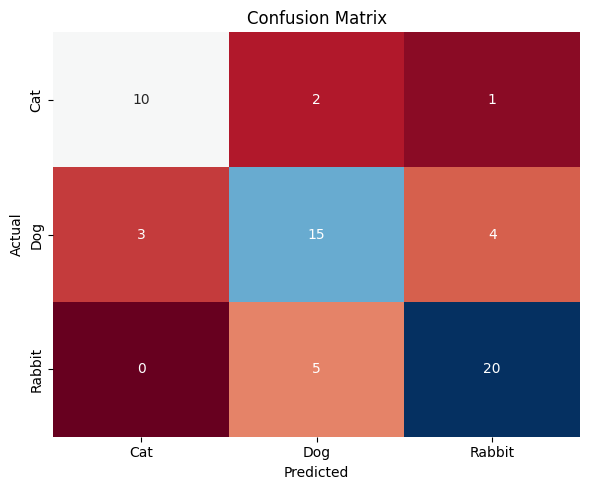

In [1]:
from simCalcFunctions import plot_confusion_matrix


# Example usage:
plot_confusion_matrix(10, 2, 1,
                      3, 15, 4,
                      0, 5, 20,
                      labels=["Cat", "Dog", "Rabbit"])
